In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['GOOGLE_API_KEY'] = os.getenv('GOOGLE_API_KEY')

### Langchain Groq to initialize the LLM

In [2]:
from langchain_groq import ChatGroq
groq_llm = ChatGroq(model="qwen/qwen3-32b", temperature=0)

### Langchain google OpenAI

In [3]:
from langchain_openai import ChatOpenAI
openai_llm = ChatOpenAI(model="gpt-5.2", temperature=0)

### Langchain google GEN AI

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
google_llm = ChatGoogleGenerativeAI(model="gemini-2.0-pro", temperature=0)

### Agent in langchain

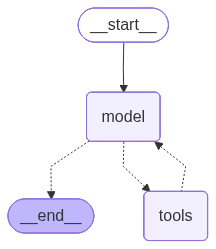

In [7]:
from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """This tool is for getting the weather of a city.
    it takes the city name as input and returns the weather information."""
    
    return f"The weather in {city} is sunny with a high of 25°C."

agent = create_agent(
    model=groq_llm,
    tools=[get_weather],
    # system_prompt="You are a helpful assistant that can provide weather information in JSON format."
)
agent

In [8]:
response = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "What is the weather in New York?"
    }]
})

In [9]:
response["messages"][-1].content

'The weather in New York is currently sunny, with a high temperature of 25°C.'

### Streaming And Batch
### Streaming

Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses. Calling stream() returns an iterator that yields output chunks as they are produced. You can use a loop to process each chunk in real-time:

In [13]:
groq_llm.invoke("Write me a 200 words paragraph on Artificial Intelligence")

AIMessage(content="<think>\nOkay, the user wants a 200-word paragraph on Artificial Intelligence. Let me start by defining AI to set the foundation. I should mention its purpose, like simulating human intelligence. Then, include key areas such as machine learning and deep learning. Maybe touch on applications in different fields—healthcare, finance, etc. Need to highlight benefits like efficiency and innovation. Also, address challenges like ethical concerns and job displacement. Make sure to balance the positives with the negatives. Keep it concise but comprehensive. Avoid technical jargon so it's accessible. Check the word count as I go. Let me structure it: intro, applications, benefits, challenges, conclusion. Maybe start with a strong opening sentence. Ensure smooth transitions between ideas. Use examples to illustrate points. Conclude with the future outlook. Let me review for clarity and flow. Okay, that should cover it without going over 200 words.\n</think>\n\nArtificial Intel

In [14]:
for chunk in groq_llm.stream("Write me a 200 words paragraph on Artificial Intelligence"):
    print(chunk.text, end="|", flush=True)

|<think>|
|Okay|,| the| user| wants| a| |2|0|0|-word| paragraph| on| Artificial| Intelligence|.| Let| me| start| by| defining| AI| to| set| the| foundation|.| I| should| mention| its| purpose|,| like| sim|ulating| human| intelligence|.| Then|,| include| key| areas| such| as| machine| learning| and| deep| learning|.| Maybe| touch| on| applications| in| different| fields|—|health|care|,| finance|,| etc|.| Need| to| highlight| benefits| like| efficiency| and| innovation|.| Also|,| address| challenges| like| ethical| concerns| and| job| displacement|.| Make| sure| to| balance| the| positives| with| the| negatives|.| Keep| it| concise| but| comprehensive|.| Avoid| technical| j|argon| so| it|'s| accessible|.| Check| the| word| count| as| I| go|.| Let| me| structure| it|:| intro|,| applications|,| benefits|,| challenges|,| conclusion|.| Maybe| start| with| a| strong| opening| sentence|.| Ensure| smooth| transitions| between| ideas|.| Use| examples| to| illustrate| points|.| Con|clude| with| t

In [15]:
for chunk in groq_llm.stream("Why do parrots have colorful feathers?"):
    print(chunk.text, end="|", flush=True)

|<think>|
|Okay|,| so| I| need| to| figure| out| why| par|rots| have| colorful| feathers|.| Let| me| start| by| recalling| what| I| know| about| par|rots|.| They|'re| known| for| their| bright| colors|—|greens|,| blues|,| red|s|,| yell|ows|.| I| remember| reading| somewhere| that| color| in| animals| can| serve| different| purposes| like| camouflage|,| communication|,| or| attracting| mates|.| Maybe| par|rots| use| their| colors| for| some| of| these| reasons|.

|First|,| maybe| it|'s| for| attracting| mates|.| In| many| bird| species|,| males| have| brighter| colors| to| show| they|'re| healthy| and| strong|.| If| a| male| par|rot| has| vibrant| feathers|,| it| might| signal| to| females| that| he|'s| a| good| genetic| choice|.| But| wait|,| some| par|rots| are| both| males| and| females| with| bright| colors|.| Does| that| mean| it|'s| not| just| about| sex|?| Or| maybe| both| genders| use| color| for| other| reasons| too|.

|Another| thought|:| camouflage|.| But| par|rots| are| usua

### Batch

 Batching a collection of independent requests to a model can significantly improve performance and reduce costs, as the processing can be done in parallel:

In [16]:
responses = groq_llm.batch([
    "Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"
])
for response in responses:
    print(response)

content="<think>\nOkay, so I need to figure out why parrots have colorful feathers. Let me start by recalling what I know about parrots. They're known for their bright colors—greens, blues, reds, yellows, etc. I remember that in the animal kingdom, coloration often serves specific purposes like camouflage, communication, or attracting mates. But parrots are usually in environments where they might be visible, so maybe camouflage isn't the main reason here.\n\nFirst thought: maybe it's for attracting mates. Like in many birds, males have brighter colors to show they're healthy and strong. But wait, some parrots are both males and females with similar colors. So maybe it's not just about sex. Also, some parrots use their colors to communicate with each other, like signaling danger or territory. But how does that work exactly?\n\nAnother angle: maybe the colors help in species recognition. Parrots are social birds, so having distinct colors could help them identify members of their own sp

In [17]:
groq_llm.batch(
    ["Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"],
    config={
        'max_concurrency': 5,  # Limit to 5 parallel calls
    }
)

[AIMessage(content="<think>\nOkay, so I need to figure out why parrots have colorful feathers. Let me start by recalling what I know about parrots. They're known for their bright colors—greens, blues, reds, yellows, etc. I remember that in the animal kingdom, coloration often serves specific purposes like camouflage, communication, or attracting mates. But parrots are usually in environments where their colors might stand out, not blend in. So maybe it's for attracting mates or signaling something else.\n\nFirst, I should consider sexual selection. In many bird species, males have brighter plumage to attract females. Parrots are mostly monogamous, so maybe the males use their colors to show they're healthy and genetically fit. But wait, some parrots have both males and females with bright colors. So maybe it's not just about sex. Also, in some species, both males and females have similar colors, so maybe there's another reason.\n\nAnother thought: maybe the colors serve as a warning to